In [10]:
import scanpy as sc
import pandas as pd
import numpy as nu
from scipy.sparse import csr_matrix

from matplotlib import pyplot as plt
from matplotlib import rcParams
import sys
import bachclue as bc
import time

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=200, facecolor='white')

In [9]:
adata = sc.read_h5ad("datasets/paul15/processed_data.h5ad")

In [11]:
adata

AnnData object with n_obs × n_vars = 2730 × 685
    obs: 'paul15_clusters', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'iroot', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [12]:
sorted(adata.obs['paul15_clusters'].unique())

['10GMP',
 '11DC',
 '12Baso',
 '13Baso',
 '14Mo',
 '15Mo',
 '16Neu',
 '17Neu',
 '18Eos',
 '19Lymph',
 '1Ery',
 '2Ery',
 '3Ery',
 '4Ery',
 '5Ery',
 '6Ery',
 '7MEP',
 '8Mk',
 '9GMP']

In [20]:
len(adata.obs['paul15_clusters'].unique())

19

In [13]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50)

2025-06-11 11:40:42.342372: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-11 11:40:42.344442: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-11 11:40:42.376837: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-11 11:40:42.394574: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749642042.427796 3255254 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749642042.43

Performing 19 parallel clusterings
Using 19/32 CPU cores
Starting parallel computation with Joblib using 19 cores...


/home/jovyan/ifbdata/spatial_cell_id/Marco/clustering_optimum/tests/../clustering_optimum/score_function.py:23: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=clustering_name, resolution=r)
/home/jovyan/ifbdata/spatial_cell_id/Marco/clustering_optimum/tests/../clustering_optimum/score_function.py:23: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=clustering_name, resolution=r)
/home/jovyan/ifbdata/spatial_cell_id/Marco/clustering_optimum/tests/../clustering_optimum/score_function.py:23: FutureWarning: In the future, the default ba


Best resolution: 0.20


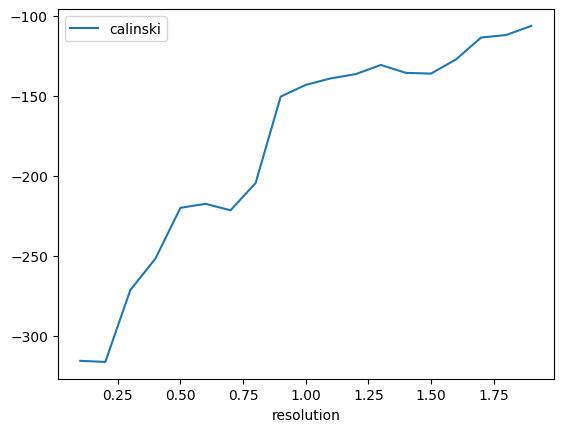

In [14]:
a = bc.clustering_score(adata, score_value = 'calinski', min_res=0.1,max_res=2.0,step=0.1, plot=True, dim_reduction = 'pca')

Performing 19 parallel clusterings
Using 19/32 CPU cores
Starting parallel computation with Joblib using 19 cores...

Best resolution: 1.90


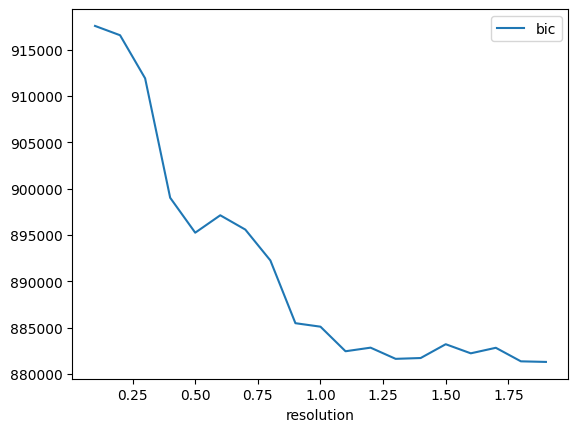

In [15]:
b = bc.clustering_score(adata, score_value = 'bic', min_res=0.1,max_res=2.0,step=0.1, plot=True, dim_reduction = 'pca')

Performing 20 parallel clusterings
Using 20/32 CPU cores
Starting parallel computation with Joblib using 20 cores...


/home/jovyan/ifbdata/spatial_cell_id/Marco/clustering_optimum/tests/../clustering_optimum/score_function.py:23: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added=clustering_name, resolution=r)



Best resolution: 0.80


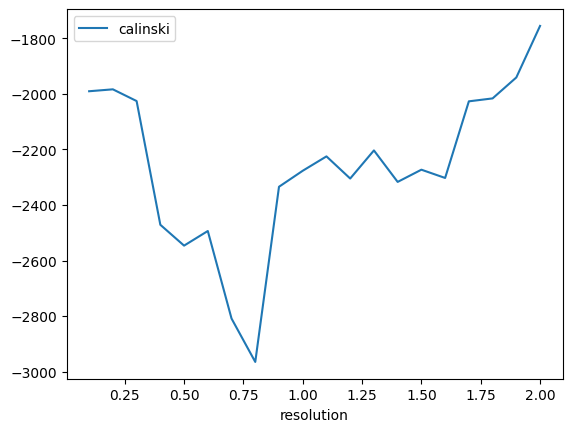

In [16]:
c = bc.clustering_score(adata, score_value = 'calinski', min_res=0.1,max_res=2.1,step=0.1, plot=True, dim_reduction = 'umap')

Performing 20 parallel clusterings
Using 20/32 CPU cores
Starting parallel computation with Joblib using 20 cores...

Best resolution: 0.10


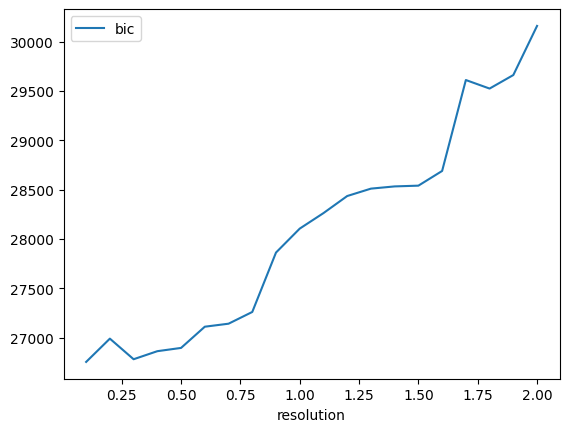

In [17]:
d = bc.clustering_score(adata, score_value = 'bic', min_res=0.1,max_res=2.1,step=0.1, plot=True, dim_reduction = 'umap')

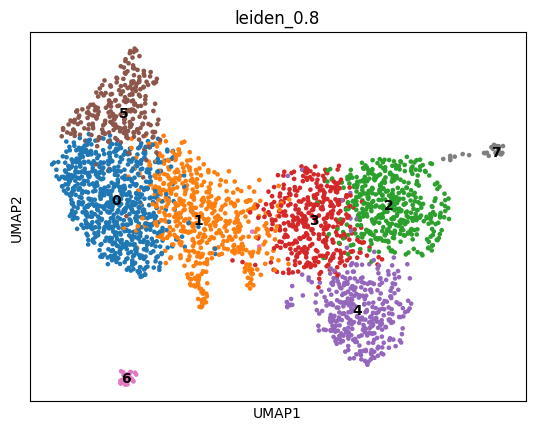

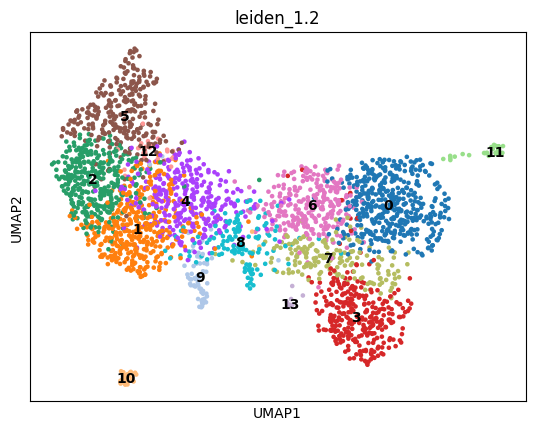

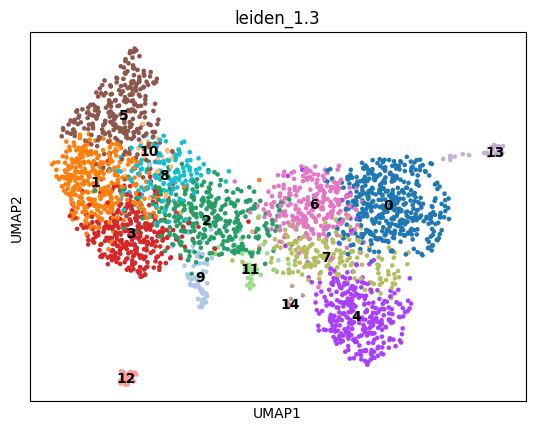

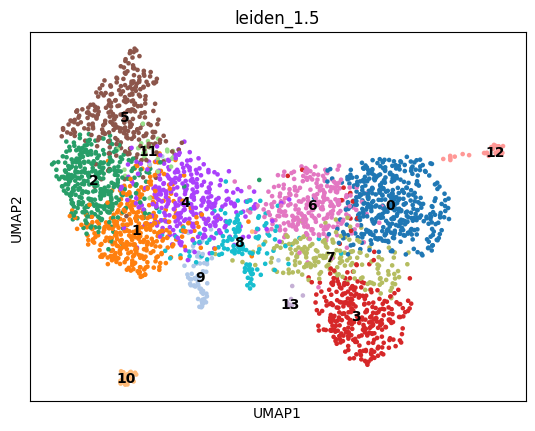

In [19]:
for res in [0.8, 1.2, 1.3, 1.5]:
    sc.tl.leiden(adata, key_added="leiden_%s" %res, resolution=res)
    sc.pl.umap(adata, color="leiden_%s" %res,legend_loc="on data")